# Boosting Models
target = `Irrigation_Need` (Low / Medium / High)

**Models:** AdaBoost, XGBoost, LightGBM  
**Tuning:** Optuna  
**Metric:** Weighted F1 

## 1. Setup

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
import lightgbm as lgb
import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED=42; 
TARGET='Irrigation_Need'; 
ORDER=['Low','Medium','High']
CAT_COLS=['Soil_Type','Crop_Type','Crop_Growth_Stage','Season',
          'Irrigation_Type','Water_Source','Mulching_Used','Region']

## 2. Load Data and Feature Engineering
Same features as bagging notebook 

In [8]:
# load training and test datasets
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

# create new features based on existing columns
for df in [train, test]:
    df['stage_mulch'] = df['Crop_Growth_Stage'].astype(str) + '_' + df['Mulching_Used'].astype(str)
    # combine two categorical features into one

    df['stress_index'] = (df['Temperature_C'] + df['Wind_Speed_kmh']) / (df['Soil_Moisture'] + 1)
    # create stress index using temperature, wind, and soil moisture

    df['water_deficit'] = df['Temperature_C'] / (df['Rainfall_mm'] / 100 + 1)
    # create water deficit feature using temperature and rainfall

FEAT_CATS = CAT_COLS + ['stage_mulch']
# list of categorical features (including new one)

oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
# encoder to convert categories into numbers (unknown values → -1)

train[FEAT_CATS] = oe.fit_transform(train[FEAT_CATS])
# fit encoder on training data and transform it

test[FEAT_CATS]  = oe.transform(test[FEAT_CATS])
# apply same encoding to test data

le = LabelEncoder(); y = le.fit_transform(train[TARGET])
# encode target labels into numbers

FEAT_COLS = [c for c in train.columns if c not in ['id', TARGET]]
# select feature columns (exclude id and target)

X = train[FEAT_COLS].values; X_test = test[FEAT_COLS].values
# convert features to numpy arrays

sample_weights = compute_sample_weight('balanced', y)
# compute weights to handle class imbalance

sample_idx = np.random.RandomState(SEED).choice(len(X), 30000, replace=False)
# randomly select 30,000 rows for a smaller training sample

X_s, y_s = X[sample_idx], y[sample_idx]
# create sampled feature matrix and target

print(f'Features: {len(FEAT_COLS)}, CV sample: {len(X_s):,} rows')
# print number of features and sample size

Features: 22, CV sample: 30,000 rows


## 3. Cross-Validation Setup

In [9]:
CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_s, y_s, test_size=0.2, stratify=y_s, random_state=SEED)
print('3-fold CV and hold-out ready.')

3-fold CV and hold-out ready.


## 4. Model 1: AdaBoost

from class:
AdaBoost reweights misclassified samples at each round. 

In [11]:
for n in [50, 100, 200]:
    ada = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3),
        n_estimators=n, learning_rate=0.5, algorithm='SAMME', random_state=SEED)
    s = cross_val_score(ada, X_s, y_s, cv=CV, scoring='f1_weighted', n_jobs=1)
    print(f'  n_estimators={n:3d}: {s.mean():.4f} +/- {s.std():.4f}')

  n_estimators= 50: 0.9735 +/- 0.0021
  n_estimators=100: 0.9747 +/- 0.0028
  n_estimators=200: 0.9732 +/- 0.0024


In [12]:
ada_best = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3),
    n_estimators=200, learning_rate=0.5, algorithm='SAMME', random_state=SEED)
s = cross_val_score(ada_best, X_s, y_s, cv=CV, scoring='f1_weighted', n_jobs=1)
m_ada, s_ada = s.mean(), s.std()
print(f'AdaBoost best CV F1: {m_ada:.4f} +/- {s_ada:.4f}')

AdaBoost best CV F1: 0.9732 +/- 0.0024


## 5. Model 2: XGBoost
 XGBoost addresses gradient boosting limitations like slow training and overfitting sometimes, tuned with optuna because i liked it best in class

In [13]:
def xgb_objective(trial):
    params = {
        'max_depth':        trial.suggest_int('max_depth', 4, 8),
        'learning_rate':    trial.suggest_float('learning_rate', 0.05, 0.2),
        'n_estimators':     trial.suggest_int('n_estimators', 200, 500),
        'subsample':        trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'gamma':            trial.suggest_float('gamma', 0, 3),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0.5, 2),
    }
    model = xgb.XGBClassifier(**params, objective='multi:softmax', num_class=3,
                               eval_metric='mlogloss', tree_method='hist',
                               n_jobs=1, random_state=SEED)
    sw = compute_sample_weight('balanced', y_tr)
    model.fit(X_tr, y_tr, sample_weight=sw, eval_set=[(X_val, y_val)], verbose=False)
    return f1_score(y_val, model.predict(X_val), average='weighted')

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(xgb_objective, n_trials=20)
print(f'Best XGBoost params: {study_xgb.best_params}')
print(f'Best F1: {study_xgb.best_value:.4f}')

Best XGBoost params: {'max_depth': 6, 'learning_rate': 0.16015346431121016, 'n_estimators': 234, 'subsample': 0.8794375189115273, 'colsample_bytree': 0.7088802154167752, 'gamma': 0.3585957770495033, 'reg_alpha': 0.6563807222714949, 'reg_lambda': 1.534096070240503}
Best F1: 0.9816


In [14]:
xgb_best = xgb.XGBClassifier(**study_xgb.best_params, objective='multi:softmax',
                               num_class=3, eval_metric='mlogloss',
                               tree_method='hist', n_jobs=1, random_state=SEED)
s = cross_val_score(xgb_best, X_s, y_s, cv=CV, scoring='f1_weighted', n_jobs=1)
m_xgb, s_xgb = s.mean(), s.std()
print(f'XGBoost CV weighted F1: {m_xgb:.4f} +/- {s_xgb:.4f}')

XGBoost CV weighted F1: 0.9823 +/- 0.0004


## 6. Model 3: LightGBM

In [15]:
def lgb_objective(trial):
    params = {
        'num_leaves':        trial.suggest_int('num_leaves', 30, 120),
        'max_depth':         trial.suggest_int('max_depth', 4, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.05, 0.25),
        'n_estimators':      trial.suggest_int('n_estimators', 200, 600),
        'subsample':         trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 80),
    }
    model = lgb.LGBMClassifier(**params, objective='multiclass', class_weight='balanced',
                                n_jobs=1, random_state=SEED, verbose=-1)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
    return f1_score(y_val, model.predict(X_val), average='weighted')

study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(lgb_objective, n_trials=20)
print(f'Best LightGBM params: {study_lgb.best_params}')
print(f'Best F1: {study_lgb.best_value:.4f}')

Best LightGBM params: {'num_leaves': 94, 'max_depth': 5, 'learning_rate': 0.21233868389911742, 'n_estimators': 474, 'subsample': 0.7595888283081395, 'colsample_bytree': 0.7977453489099655, 'min_child_samples': 14}
Best F1: 0.9811


In [16]:
lgb_best = lgb.LGBMClassifier(**study_lgb.best_params, objective='multiclass',
                                class_weight='balanced', n_jobs=1, random_state=SEED, verbose=-1)
s = cross_val_score(lgb_best, X_s, y_s, cv=CV, scoring='f1_weighted', n_jobs=1)
m_lgb, s_lgb = s.mean(), s.std()
print(f'LightGBM CV weighted F1: {m_lgb:.4f} +/- {s_lgb:.4f}')

LightGBM CV weighted F1: 0.9817 +/- 0.0006


## 7. Boosting Model Comparison

AdaBoost    : 0.9732 +/- 0.0024
XGBoost     : 0.9823 +/- 0.0004
LightGBM    : 0.9817 +/- 0.0006


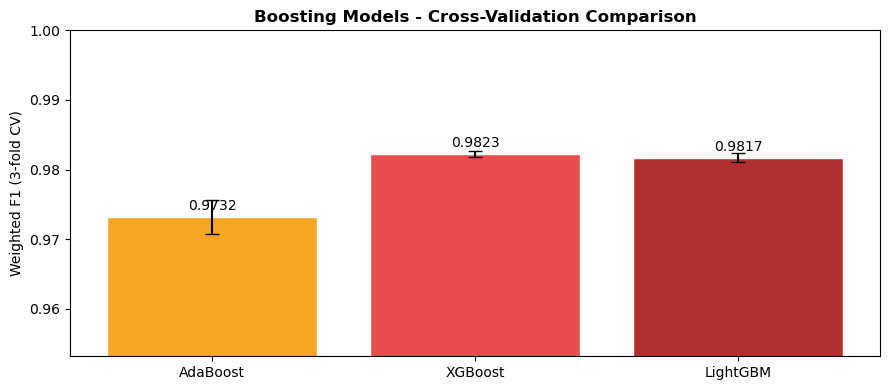

In [17]:
# Map model names to their fitted model objects
models = {
    'AdaBoost': ada_best,
    'XGBoost':  xgb_best,
    'LightGBM': lgb_best,
}

# Run CV for each model and store mean/std
boosting_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_s, y_s, cv=CV, scoring='f1_weighted', n_jobs=1)
    boosting_results[name] = (scores.mean(), scores.std())
    print(f'{name:12s}: {scores.mean():.4f} +/- {scores.std():.4f}')

# Plot results
fig, ax = plt.subplots(figsize=(9, 4))
names = list(boosting_results.keys())
means = [boosting_results[n][0] for n in names]
stds  = [boosting_results[n][1] for n in names]
bars = ax.bar(names, means, yerr=stds, capsize=5,
              color=['#F5A623','#E84C4C','#B03030'], edgecolor='white')

# Set y-axis floor just below the lowest mean for better readability
ax.set_ylim(min(means) - 0.02, 1.00)
ax.set_ylabel('Weighted F1 (3-fold CV)')
ax.set_title('Boosting Models - Cross-Validation Comparison', fontweight='bold')

# Annotate each bar with its exact value
for bar, val in zip(bars, means):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f'{val:.4f}', ha='center', fontsize=10)
plt.tight_layout(); plt.show()

## 8. Best Model XGBoost, further testing

In [20]:
# Re-fit the best XGBoost model on the training split for hold-out evaluation
# Using xgb_best which has the tuned params from Optuna
xgb_eval = xgb.XGBClassifier(**study_xgb.best_params,
                               objective='multi:softmax',
                               num_class=3,
                               eval_metric='mlogloss',
                               tree_method='hist',
                               n_jobs=1,
                               random_state=SEED)

xgb_eval.fit(X_tr, y_tr,
             sample_weight=compute_sample_weight('balanced', y_tr))

# Predict on hold-out validation set
y_pred = xgb_eval.predict(X_val)

# Full breakdown by class - pay attention to High recall given class imbalance
print(classification_report(y_val, y_pred, target_names=le.classes_))
print(f'Weighted F1 : {f1_score(y_val, y_pred, average="weighted"):.4f}')
print(f'Macro   F1  : {f1_score(y_val, y_pred, average="macro"):.4f}')

              precision    recall  f1-score   support

        High       0.93      0.94      0.94       205
         Low       0.98      0.99      0.99      3505
      Medium       0.98      0.97      0.98      2290

    accuracy                           0.98      6000
   macro avg       0.97      0.97      0.97      6000
weighted avg       0.98      0.98      0.98      6000

Weighted F1 : 0.9816
Macro   F1  : 0.9669


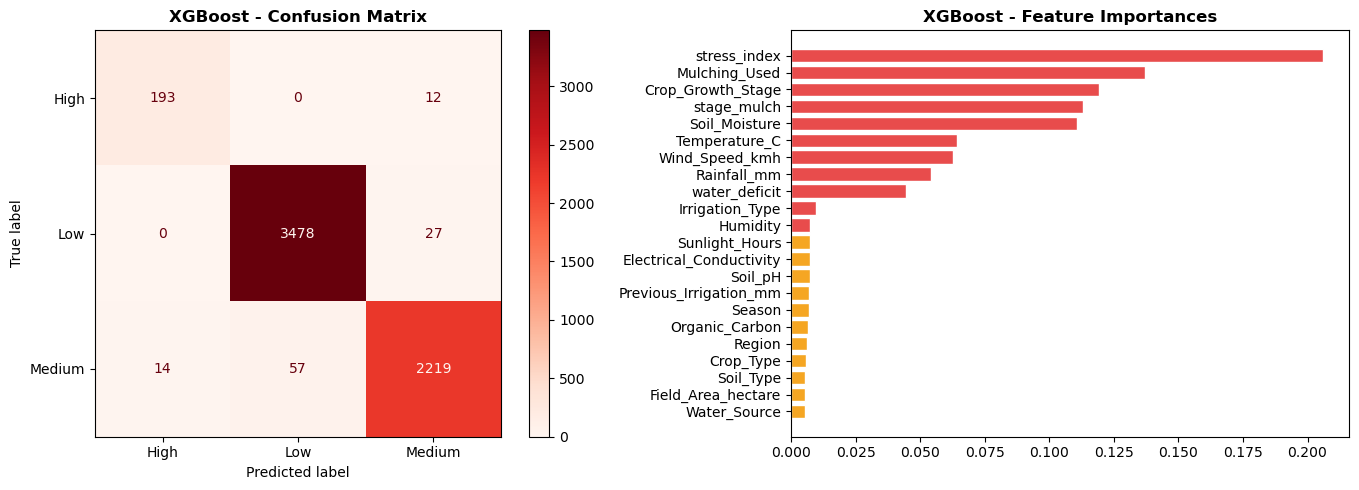

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix - rows are true labels, columns are predicted
# Look for misclassifications in the High row since it's the minority class
ConfusionMatrixDisplay(confusion_matrix(y_val, y_pred),
                       display_labels=le.classes_).plot(ax=axes[0], cmap='Reds')
axes[0].set_title('XGBoost - Confusion Matrix', fontweight='bold')

# Feature importances by gain - how much each feature reduces loss across all splits
# Red = above median importance, yellow = below median
imp = pd.Series(xgb_eval.feature_importances_, index=FEAT_COLS).sort_values()
c = ['#E84C4C' if v > imp.median() else '#F5A623' for v in imp]
axes[1].barh(imp.index, imp.values, color=c, edgecolor='white')
axes[1].set_title('XGBoost - Feature Importances', fontweight='bold')

plt.tight_layout(); plt.show()

## 9. Kaggle Submission 

In [24]:
# Fit on 200K sample (memory/time constraint; use full data on Kaggle)
full_idx = np.random.RandomState(SEED).choice(len(X), 200000, replace=False)

# Use Optuna-tuned params from earlier in the notebook
xgb_sub = xgb.XGBClassifier(**study_xgb.best_params,
                              objective='multi:softmax',
                              num_class=3,
                              eval_metric='mlogloss',
                              tree_method='hist',
                              n_jobs=1,
                              random_state=SEED)

# Pass balanced sample weights since XGBoost doesn't have a class_weight param
xgb_sub.fit(X[full_idx], y[full_idx],
            sample_weight=compute_sample_weight('balanced', y[full_idx]))

# Build submission in the same format as the original code
submission = pd.DataFrame({'id': test['id'],
                            TARGET: le.inverse_transform(xgb_sub.predict(X_test))})
submission.to_csv('submission_boosting.csv', index=False)
print('Saved: submission_boosting.csv')
print(submission[TARGET].value_counts())

Saved: submission_boosting.csv
Irrigation_Need
Low       159844
Medium    101188
High        8968
Name: count, dtype: int64
